# Case: Cross-sensor intercomparison — reflectance, FLMS vs. all sensors, Plot 103

**Reference:** Werfeli, Mihai et al. (2026), *"Uncertainty propagation and
intercomparison of multi-sensor measurements of vegetation stress in
sub-optimal conditions."*

This notebook compares **Piccolo Doppio FLMS** reflectance against all 9
other sensor/panel combinations measured at Plot 103: QEP, ASD (WP1 and
WP2), SVC (WP1 and WP2), Altum (GP and WP2), REMX (GP and WP2).

The reflectance spectrum is compared using the normalised error:

$$E_N = \frac{R_x - R_y}{\sqrt{u_c(R_x)^2 + u_c(R_y)^2}}$$

where $x$ is always FLMS (the reference) and $y$ is the other sensor.
$|E_N| \le 1$ means the difference between the two sensors is fully
explained by their own combined uncertainties; $|E_N| > 1$ means it is not.

For the equivalent comparison of the five vegetation indices, see
[`case_intercomparison-Ex3_Indices_AllSensors.ipynb`](case_intercomparison-Ex3_Indices_AllSensors.ipynb) —
kept as a separate notebook, matching the two separate real scripts this
material is based on.

In [1]:
import numpy as np
import openpyxl

DATA_DIR = "../data/case-intercomparison-plot103-full"
FILE = f"{DATA_DIR}/Indexes-7_cos_16062026.xlsx"
wb = openpyxl.load_workbook(FILE, data_only=True, read_only=True)

## 1. Reading the reflectance data

`Reflectance_103_all` has one block of columns per sensor/panel, laid out
exactly as in the original workbook (this is the real column mapping used
by the MATLAB code — not re-derived):

- FLMS, QEP: columns 1-7 / 8-14 — wavelength, reflectance, u_random,
  u_systematic, (blank), u_combined (1σ), U_expanded (k=2)
- ASD, SVC: columns 15-25 / 26-36 — one shared wavelength column, then
  WP1/WP2 reflectance and uncertainty columns interleaved
- Altum, REMX (GP and WP2): columns 37-60 — wavelength, reflectance,
  u_panel, u_plot, u_ROI, u_total (already combined)

Loaded 1478 spectral rows for Plot 103.


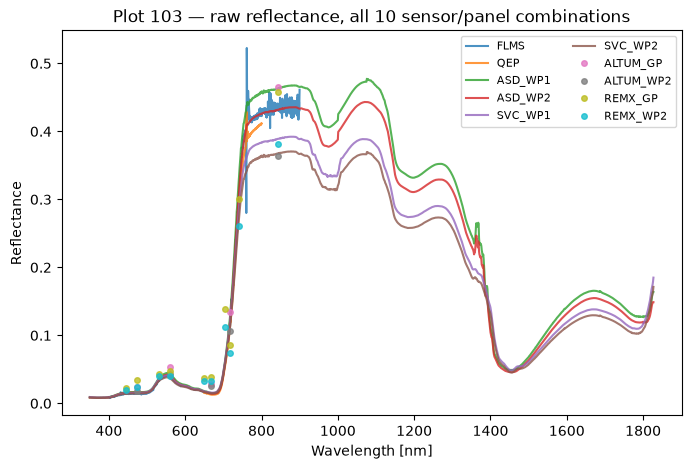

In [2]:
ws = wb["Reflectance_103_all"]
nrows = 0
for r in ws.iter_rows(min_row=3, values_only=True):
    if r[0] is None:
        break
    nrows += 1

A = np.full((nrows, 60), np.nan)
for i, row in enumerate(ws.iter_rows(min_row=3, max_row=2 + nrows, values_only=True)):
    for c in range(60):
        v = row[c]
        A[i, c] = np.nan if v is None else v

def col(c):  # 1-indexed column, matching the original code
    return A[:, c - 1]

FLMS = np.column_stack([col(c) for c in range(1, 8)])
QEP = np.column_stack([col(c) for c in range(8, 15)])
ASD_WP1 = np.column_stack([col(15), col(16), col(18), col(20), col(22), col(24)])
ASD_WP2 = np.column_stack([col(15), col(17), col(19), col(21), col(23), col(25)])
SVC_WP1 = np.column_stack([col(26), col(27), col(29), col(31), col(33), col(35)])
SVC_WP2 = np.column_stack([col(26), col(28), col(30), col(32), col(34), col(36)])
Altum_GP = np.column_stack([col(c) for c in range(37, 43)])
Altum_WP2 = np.column_stack([col(c) for c in range(43, 49)])
REMX_GP = np.column_stack([col(c) for c in range(49, 55)])
REMX_WP2 = np.column_stack([col(c) for c in range(55, 61)])

# (name, block, index of the combined-uncertainty column within that block, 1-indexed)
sensors = [
    ("FLMS", FLMS, 6), ("QEP", QEP, 6),
    ("ASD_WP1", ASD_WP1, 5), ("ASD_WP2", ASD_WP2, 5),
    ("SVC_WP1", SVC_WP1, 5), ("SVC_WP2", SVC_WP2, 5),
    ("ALTUM_GP", Altum_GP, 6), ("ALTUM_WP2", Altum_WP2, 6),
    ("REMX_GP", REMX_GP, 6), ("REMX_WP2", REMX_WP2, 6),
]
print(f"Loaded {nrows} spectral rows for Plot 103.")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
for name, block, ucol in sensors:
    w, r, u = block[:, 0], block[:, 1], block[:, ucol - 1]
    m = np.isfinite(w) & np.isfinite(r)
    style = 'o' if ("ALTUM" in name or "REMX" in name) else '-'
    plt.plot(w[m], r[m], style, label=name, markersize=4, alpha=0.8)
plt.xlabel('Wavelength [nm]'); plt.ylabel('Reflectance')
plt.legend(fontsize=8, ncol=2); plt.title('Plot 103 — raw reflectance, all 10 sensor/panel combinations')
plt.show()

## 2. Matching wavelengths between sensors

FLMS, QEP, ASD and SVC are hyperspectral (dense wavelength sampling);
Altum and REMX are multispectral (a handful of fixed band centers). Three
matching strategies are used, exactly as in the original code, depending
on which pair of sensors is being compared:

1. **Hyperspectral vs. hyperspectral** — both spectra are linearly
   interpolated onto a common 1nm grid, over their overlapping wavelength
   range.
2. **Hyperspectral vs. multispectral** — the hyperspectral spectrum is
   linearly interpolated onto the multispectral sensor's own (fixed) band
   centers.
3. **Multispectral vs. multispectral** — bands are matched by nearest
   wavelength, within a 1nm tolerance.

In [3]:
def is_multispectral(name):
    return "ALTUM" in name or "REMX" in name

def extract_wru(B, ucol):
    w, r, u = B[:, 0], B[:, 1], B[:, ucol - 1]
    m = np.isfinite(w) & np.isfinite(r) & np.isfinite(u)
    w, r, u = w[m], r[m], u[m]
    idx = np.argsort(w)
    return w[idx], r[idx], u[idx]

def match_hyperspec_pair(BX, uX, BY, uY, grid_nm=1.0):
    wx, rx, ux = extract_wru(BX, uX)
    wy, ry, uy = extract_wru(BY, uY)
    wlmin, wlmax = max(wx.min(), wy.min()), min(wx.max(), wy.max())
    if wlmax <= wlmin:
        return (np.array([]),) * 5
    wl = np.arange(np.ceil(wlmin), np.floor(wlmax) + 1, grid_nm)
    Rx = np.interp(wl, wx, rx, left=np.nan, right=np.nan)
    ucx = np.interp(wl, wx, ux, left=np.nan, right=np.nan)
    Ry = np.interp(wl, wy, ry, left=np.nan, right=np.nan)
    ucy = np.interp(wl, wy, uy, left=np.nan, right=np.nan)
    m = np.isfinite(wl) & np.isfinite(Rx) & np.isfinite(Ry) & np.isfinite(ucx) & np.isfinite(ucy)
    return wl[m], Rx[m], ucx[m], Ry[m], ucy[m]

def match_hyperspec_to_multispec(Bhyp, uHyp, Bmulti, uMulti):
    wm, rm, um = extract_wru(Bmulti, uMulti)
    wh, rh, uh = extract_wru(Bhyp, uHyp)
    if len(wh) < 2 or len(wm) == 0:
        return (np.array([]),) * 5
    Rh = np.interp(wm, wh, rh, left=np.nan, right=np.nan)
    uch = np.interp(wm, wh, uh, left=np.nan, right=np.nan)
    m = np.isfinite(wm) & np.isfinite(Rh) & np.isfinite(uch) & np.isfinite(rm) & np.isfinite(um)
    return wm[m], Rh[m], uch[m], rm[m], um[m]

def match_multispec_pair(BX, uX, BY, uY, tol=1.0):
    wx, rx, ux = extract_wru(BX, uX)
    wy, ry, uy = extract_wru(BY, uY)
    wl, Rx, ucx, Ry, ucy = [], [], [], [], []
    for i in range(len(wx)):
        d = np.abs(wy - wx[i])
        j = np.argmin(d)
        if d[j] <= tol:
            wl.append(wx[i]); Rx.append(rx[i]); ucx.append(ux[i])
            Ry.append(ry[j]); ucy.append(uy[j])
    return tuple(np.array(v) for v in (wl, Rx, ucx, Ry, ucy))

def match_pair_general(nameX, BX, uX, nameY, BY, uY):
    isX, isY = is_multispectral(nameX), is_multispectral(nameY)
    if not isX and not isY:
        return match_hyperspec_pair(BX, uX, BY, uY)
    elif not isX and isY:
        return match_hyperspec_to_multispec(BX, uX, BY, uY)
    elif isX and not isY:
        wl, Ry, ucy, Rx, ucx = match_hyperspec_to_multispec(BY, uY, BX, uX)
        return wl, Rx, ucx, Ry, ucy
    else:
        return match_multispec_pair(BX, uX, BY, uY)

## 3. E_N agreement — reflectance, FLMS vs. every other sensor

FLMS vs QEP       : N= 149  r=0.996  bias=+0.01120  %|En|<=1= 96.0%  %|En|<=2= 99.3%
FLMS vs ASD_WP1   : N= 499  r=0.999  bias=-0.01112  %|En|<=1= 98.8%  %|En|<=2= 99.8%
FLMS vs ASD_WP2   : N= 499  r=0.999  bias=+0.00019  %|En|<=1= 99.6%  %|En|<=2= 99.8%
FLMS vs SVC_WP1   : N= 499  r=0.999  bias=+0.01377  %|En|<=1= 98.2%  %|En|<=2=100.0%
FLMS vs SVC_WP2   : N= 499  r=0.999  bias=+0.02191  %|En|<=1= 93.8%  %|En|<=2=100.0%
FLMS vs ALTUM_GP  : N=   5  r=1.000  bias=-0.01778  %|En|<=1= 20.0%  %|En|<=2= 20.0%
FLMS vs ALTUM_WP2 : N=   5  r=1.000  bias=+0.01161  %|En|<=1= 60.0%  %|En|<=2= 80.0%
FLMS vs REMX_GP   : N=  10  r=0.984  bias=-0.01647  %|En|<=1= 20.0%  %|En|<=2= 30.0%
FLMS vs REMX_WP2  : N=  10  r=0.987  bias=+0.00236  %|En|<=1= 20.0%  %|En|<=2= 50.0%


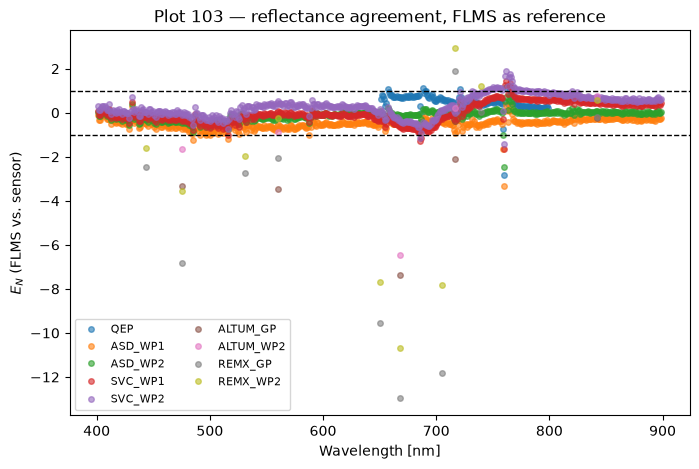

In [4]:
def en_metrics(wl, Rx, ucx, Ry, ucy):
    den = np.sqrt(ucx**2 + ucy**2)
    En = (Rx - Ry) / den
    r = np.corrcoef(Rx, Ry)[0, 1] if len(Rx) > 1 else np.nan
    return dict(
        N=len(wl), r_Pearson=r,
        bias_mean=np.nanmean(Rx - Ry),
        RMSE=np.sqrt(np.nanmean((Rx - Ry) ** 2)),
        En_mean=np.nanmean(En),
        pct_absEn_le_1=100 * np.mean(np.abs(En) <= 1),
        pct_absEn_le_2=100 * np.mean(np.abs(En) <= 2),
    ), En

reflectance_results = {}
for name, block, ucol in sensors:
    if name == "FLMS":
        continue
    wl, Rx, ucx, Ry, ucy = match_pair_general("FLMS", FLMS, 6, name, block, ucol)
    if len(wl) < 3:
        print(f"FLMS vs {name}: not enough spectral overlap")
        continue
    M, En = en_metrics(wl, Rx, ucx, Ry, ucy)
    reflectance_results[name] = (wl, En, M)
    print(f"FLMS vs {name:10s}: N={M['N']:4d}  r={M['r_Pearson']:.3f}  "
          f"bias={M['bias_mean']:+.5f}  %|En|<=1={M['pct_absEn_le_1']:5.1f}%  %|En|<=2={M['pct_absEn_le_2']:5.1f}%")

plt.figure(figsize=(8, 5))
for name, (wl, En, M) in reflectance_results.items():
    plt.plot(wl, En, 'o', label=name, markersize=4, alpha=0.6)
plt.axhline(1, color='k', linestyle='--', linewidth=1)
plt.axhline(-1, color='k', linestyle='--', linewidth=1)
plt.xlabel('Wavelength [nm]'); plt.ylabel('$E_N$ (FLMS vs. sensor)')
plt.legend(fontsize=8, ncol=2); plt.title('Plot 103 — reflectance agreement, FLMS as reference')
plt.show()

---

**Code:** L. Mihai (laura.mihai@inflpr.ro) and Mike Werfeli (mike.werfeli@geo.uzh.ch)  
**Training material:** L. Mihai (laura.mihai@inflpr.ro)